In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [3]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [4]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [5]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.184125,-0.257263,1.581113,1.286072,0.666516,0.159184,-0.672874,0.617812,-0.546221,-0.291195,...,0.708101,1.055111,1.522050,-0.203173,-0.001456,-0.429469,-0.589448,-0.355738,0.0,No Anomaly
1,-1.062708,-1.259745,-0.613106,3.833526,-2.625213,-1.239047,1.706160,-1.459608,-0.107152,0.921513,...,-2.433095,-1.014099,-0.487619,-1.060791,-0.002286,-0.640056,-0.330920,-0.583591,0.0,No Anomaly
2,-0.209568,-0.290639,0.522339,6.404230,0.562926,0.409818,-0.610213,0.617812,-0.427436,-0.107134,...,0.437922,2.963968,0.480366,2.597473,-0.001444,-0.441478,-0.417494,2.087671,0.0,No Anomaly
3,-0.019643,-0.135271,1.619100,1.286072,0.226550,0.119161,-0.019022,0.595717,-0.541599,-0.288801,...,0.202856,1.030479,1.653457,-0.296382,-0.001210,-0.362647,-0.621553,-0.344701,0.0,No Anomaly
4,-0.817353,-0.871337,-0.429185,-1.377820,0.394365,-2.120745,0.208918,-0.486969,-0.206813,-0.253327,...,1.706924,-0.778885,-0.402632,-0.779790,-0.002495,-0.590065,-0.153602,-0.960638,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,-0.184007,-0.073557,0.058691,0.680315,0.111652,0.528699,-0.990652,0.650922,-0.353851,-0.316243,...,-0.173307,0.863434,-0.014343,0.977464,-0.002055,-0.397258,-0.312148,0.877764,7.0,Sharp Water Increase (Circuit)
312021,-0.197794,-0.090196,0.049789,0.654220,0.111977,0.560178,-0.980170,0.668455,-0.351857,-0.318863,...,-0.191222,0.871661,-0.022111,0.998320,-0.002062,-0.405494,-0.309745,0.902080,7.0,Sharp Water Increase (Circuit)
312022,-0.210161,-0.090148,0.044783,0.668512,0.131008,0.558595,-0.947098,0.665013,-0.350220,-0.318027,...,-0.167440,0.873533,-0.024019,1.003277,-0.002110,-0.408323,-0.308039,0.899294,7.0,Sharp Water Increase (Circuit)
312023,-0.186203,-0.069973,0.060316,0.643991,0.127371,0.544015,-0.935105,0.657681,-0.353139,-0.318188,...,-0.163331,0.856686,-0.007690,0.960066,-0.002074,-0.397767,-0.313261,0.859037,7.0,Sharp Water Increase (Circuit)


In [6]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.226693,-0.275825,1.134546,1.286072,0.618626,0.287604,-0.315850,0.610675,-0.499790,-0.290426,...,0.575898,1.047155,1.125280,0.046156,-0.001578,-0.441977,-0.535424,-0.121662,0.0,No Anomaly
1,-1.062378,-1.257910,-1.493644,-1.284632,-2.724986,-1.416380,-0.045617,-1.481273,0.417720,0.237420,...,-2.449832,-1.526558,-1.498052,-1.123355,-0.002313,-0.639282,0.339976,-0.651612,0.0,No Anomaly
2,-1.062892,-1.263033,-1.498645,1.274447,-2.588058,-1.258002,-3.127022,-1.481273,0.288082,0.602667,...,-2.377440,-1.286072,-1.622596,-0.187779,-0.002227,-0.639857,0.534325,0.395166,0.0,No Anomaly
3,-1.063948,-1.259333,-1.049357,1.274447,-2.568197,-1.237739,0.393138,-1.591751,0.066799,0.824058,...,-2.365365,-1.409064,-1.025145,-1.328769,-0.002329,-0.636267,-0.066158,-0.901500,12.0,Inlet Valve Malfunction
4,-0.220146,-0.234965,1.128661,3.845151,0.886929,-0.204674,-0.888359,0.544190,-0.506847,-0.188557,...,1.184454,1.902423,1.046683,0.859182,-0.001696,-0.427459,-0.511730,0.416942,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.067784,-1.270137,-1.020789,1.274447,-2.467807,-1.166853,-0.285622,-1.503368,0.028804,0.641232,...,-2.285989,-1.310670,-1.033044,-1.124995,-0.002224,-0.640668,-0.051517,-0.686422,12.0,Inlet Valve Malfunction
7377,-0.231683,-0.282715,0.954671,1.286072,0.677298,0.240503,-1.248497,0.595717,-0.492975,-0.288801,...,0.673768,1.030479,0.832035,0.256600,-0.001575,-0.443208,-0.483454,0.035520,0.0,No Anomaly
7378,-1.066053,-1.270531,-1.771689,1.274447,-2.679662,-1.328452,-0.456350,-1.480572,0.809369,0.601484,...,-2.446516,-1.285292,-1.791381,0.288445,-0.002164,-0.641029,0.836518,0.962475,0.0,No Anomaly
7379,-0.076310,-0.166736,0.653042,3.845151,0.119827,0.345037,2.285026,0.626297,-0.401679,-0.200351,...,-0.056691,2.021884,0.931473,1.080517,-0.001328,-0.386631,-0.525238,0.934887,0.0,No Anomaly


In [7]:
X_train_scaled = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test_scaled = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [8]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [9]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### Logistic Regression

In [10]:
model = LogisticRegression(
                                solver='newton-cholesky', 
                                multi_class='ovr', 
                                C=20) # 'lbfgs' is a good general-purpose solver
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8385


In [11]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

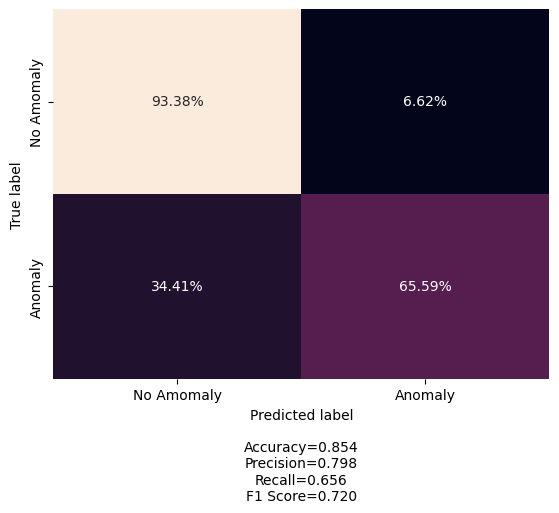

In [12]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Random Forest Classifier

In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9378


In [14]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

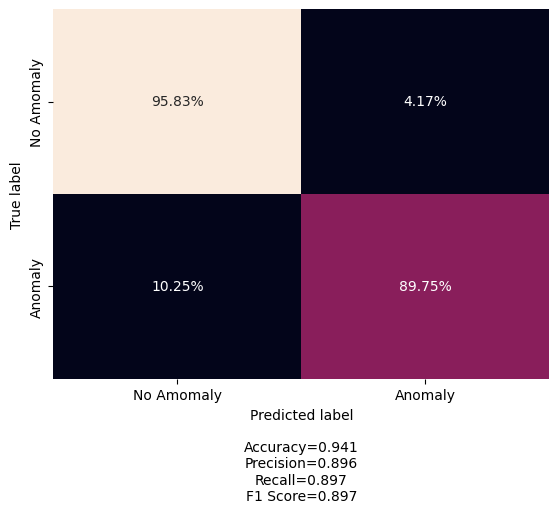

In [15]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### XGBoost

In [16]:
model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9323


In [17]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

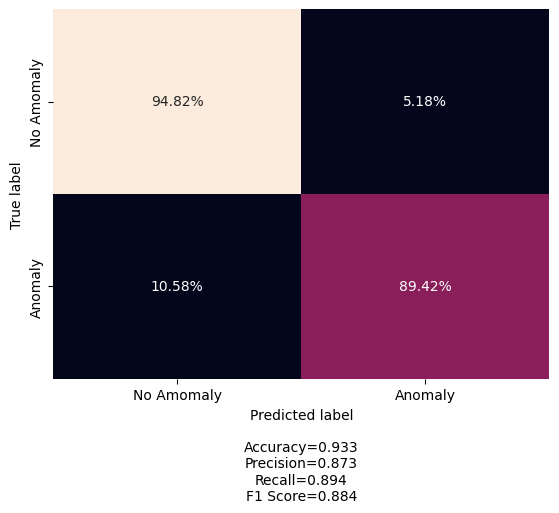

In [18]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### SVM

In [19]:
# # 3. Instantiate and Train SVM
# svm_model = SVC(kernel='linear', C=5.0, probability=True) # Example with RBF kernel
# svm_model.fit(X_train_scaled, y_train)

# # 4. Make Predictions and Evaluate
# y_pred = svm_model.predict(X_test_scaled)
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Model Accuracy: {accuracy:.4f}")

In [20]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

In [21]:
# plot.make_confusion_matrix(
#     format_cf(confusion_matrix(y_test, y_pred)),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )